# Hierarchical Insect Classifier — Baseline 

CSV facts (hierarchical_labels_v15.csv)
| Property | Value |
|---|---|
| Total samples | 37,588 (train 28,466 / val 7,120 / test 2,002) |
| Species present | 1-3, 5-12, 14-18, 21-31 |
| l1_pest | 0=non-pest, 1=pest |
| l2_role | 0=predator, 1=non-predator, -1=masked |
| l3_pred_type | 0=ladybug-pred, 1=other-pred, -1=masked |
| l3_nonpred_type | 0=ladybug-nonpred, 1=other-nonpred, -1=masked |
| sp_pred_ladybug_common | 0-10 → sp1-3,5-12 (11 classes), -1=masked |
| sp_other_pred | 0-2 → sp14-16 (3 classes), -1=masked |
| sp_nonpred_ladybug | 0-1 → sp17-18 (2 classes), -1=masked |

## Hierarchy
```
level1 (pest/non-pest)
├── 0 → sp21 (non-pest, terminal)
└── 1 → level2 (predator role)
    ├── 0 (predator) → l3a (pred type)
    │   ├── 0 (ladybug-pred) → l4a: 11 classes → sp1,2,3,5,6,7,8,9,10,11,12
    │   └── 1 (other-pred)   → l4b:  3 classes → sp14,15,16
    └── 1 (non-predator) → l3b (nonpred type)
        ├── 0 (ladybug-nonpred) → l4c: 2 classes → sp17,18
        └── 1 (other-nonpred)   → sp22-31 (terminal, merged as sp22

In [1]:
!pip install timm scikit-learn pandas pillow tqdm -q

,
,[notice] A new release of pip is available: 24.2 -> 26.0.1
,[notice] To update, run: python -m pip install --upgrade pip


## 1. Dataset

In [1]:
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms


class HierarchicalInsectDataset(Dataset):
  
    def __init__(self, csv_file, split, img_size=224):
        df = pd.read_csv(csv_file)
        self.df = df[df["split"] == split].reset_index(drop=True)

        # No augmentation — identical transform for all splits
        self.transform = transforms.Compose([
            transforms.Resize(int(img_size * 256 / 224)),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)
        labels = {
            "level1": torch.tensor(row["l1_pest"],                dtype=torch.long),
            "level2": torch.tensor(row["l2_role"],                dtype=torch.long),
            "l3a":    torch.tensor(row["l3_pred_type"],           dtype=torch.long),
            "l3b":    torch.tensor(row["l3_nonpred_type"],        dtype=torch.long),
            "l4a":    torch.tensor(row["sp_pred_ladybug_common"], dtype=torch.long),
            "l4b":    torch.tensor(row["sp_other_pred"],          dtype=torch.long),
            "l4c":    torch.tensor(row["sp_nonpred_ladybug"],     dtype=torch.long),
            "species_id": torch.tensor(row["species_id"],         dtype=torch.long),
        }
        return img, labels


<class 'ModuleNotFoundError'>: No module named 'torch'

## 2. Model

In [2]:
import torch
import torch.nn as nn
import timm


class EfficientNetHierarchicalBaseline(nn.Module):
   

    def __init__(self, backbone="efficientnet_b0", pretrained=True, feat_dim=512):
        super().__init__()

        self.backbone = timm.create_model(
            backbone,
            pretrained=pretrained,
            num_classes=0,
        )
        in_features = self.backbone.num_features  # 1280 for B0

        self.shared = nn.Sequential(
            nn.Linear(in_features, feat_dim),
            nn.BatchNorm1d(feat_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )

        self.head_level1 = nn.Linear(feat_dim, 2)
        self.head_level2 = nn.Linear(feat_dim, 2)
        self.head_l3a    = nn.Linear(feat_dim, 2)
        self.head_l3b    = nn.Linear(feat_dim, 2)
        self.head_l4a    = nn.Linear(feat_dim, 11)  # sp_pred_ladybug_common: 11 classes
        self.head_l4b    = nn.Linear(feat_dim, 3)   # sp_other_pred: 3 classes
        self.head_l4c    = nn.Linear(feat_dim, 2)   # sp_nonpred_ladybug: 2 classes

        self._init_weights()

    def _init_weights(self):
        for m in self.shared:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
        for head in [
            self.head_level1, self.head_level2,
            self.head_l3a,    self.head_l3b,
            self.head_l4a,    self.head_l4b, self.head_l4c,
        ]:
            nn.init.xavier_normal_(head.weight)
            nn.init.zeros_(head.bias)

    def forward(self, x):
        feats = self.shared(self.backbone(x))  # (B, feat_dim)
        return {
            "level1": self.head_level1(feats),
            "level2": self.head_level2(feats),
            "l3a":    self.head_l3a(feats),
            "l3b":    self.head_l3b(feats),
            "l4a":    self.head_l4a(feats),
            "l4b":    self.head_l4b(feats),
            "l4c":    self.head_l4c(feats),
        }


<class 'ModuleNotFoundError'>: No module named 'torch'

## 3. Loss

In [3]:
import torch
import torch.nn as nn


class HierarchicalBaselineLoss(nn.Module):
    """
    Flat multi-task CrossEntropyLoss across all 7 heads.

    The v15 CSV already uses -1 for masked/irrelevant positions in all
    downstream label columns, so ignore_index=-1 is sufficient — no
    manual gating is needed for l2/l3/l4 heads.

    The only gating applied here is for level1: non-pest samples should
    not drive gradients through level2 and below. Their CSV labels are
    already -1 for those columns, so this is handled automatically.

    All task weights = 1.0 (flat baseline).
    """

    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(ignore_index=-1)

        self.task_weights = {
            "level1": 1.0,
            "level2": 1.0,
            "l3a":    1.0,
            "l3b":    1.0,
            "l4a":    1.0,
            "l4b":    1.0,
            "l4c":    1.0,
        }

    def forward(self, outputs, targets):
        device = outputs["level1"].device
        total_loss = torch.tensor(0.0, device=device, requires_grad=True)
        loss_components = {}

        # Map output head names to the corresponding target keys
        target_keys = {
            "level1": "level1",
            "level2": "level2",
            "l3a":    "l3a",
            "l3b":    "l3b",
            "l4a":    "l4a",
            "l4b":    "l4b",
            "l4c":    "l4c",
        }

        for head, weight in self.task_weights.items():
            loss_val = self.ce(outputs[head], targets[target_keys[head]])
            if torch.isfinite(loss_val):
                total_loss = total_loss + weight * loss_val
                loss_components[head] = loss_val.item()

        return total_loss, loss_components


## 4. Helper: decode outputs → species_id

Mapping derived directly from v15 CSV:

| Head | Class | Species ID |
|---|---|---|
| level1==0 | — | 21 |
| l4a | 0 | 1 |
| l4a | 1 | 2 |
| l4a | 2 | 3 |
| l4a | 3 | 5 |
| l4a | 4 | 6 |
| l4a | 5 | 7 |
| l4a | 6 | 8 |
| l4a | 7 | 9 |
| l4a | 8 | 10 |
| l4a | 9 | 11 |
| l4a | 10 | 12 |
| l4b | 0 | 14 |
| l4b | 1 | 15 |
| l4b | 2 | 16 |
| l4c | 0 | 17 |
| l4c | 1 | 18 |
| level2==1 + l3b==1 | — | 22 (merged 22-31) |

In [4]:
import torch

# v15: l4a class → species_id lookup (11 entries, verified against CSV)
_L4A_TO_SPECIES = torch.tensor([1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12], dtype=torch.long)


def predict_species_id(outputs, device=None):
    """
    Decode 7-head logits to a single species_id per sample.

    Returns a LongTensor of shape (B,).
    Unresolved paths are left as -1 (should not occur on valid data).
    """
    B      = outputs["level1"].shape[0]
    dev    = outputs["level1"].device
    preds  = torch.full((B,), -1, dtype=torch.long, device=dev)

    l1  = outputs["level1"].argmax(1)   # 0=non-pest, 1=pest
    l2  = outputs["level2"].argmax(1)   # 0=predator, 1=non-predator
    l3a = outputs["l3a"].argmax(1)      # 0=ladybug-pred, 1=other-pred
    l3b = outputs["l3b"].argmax(1)      # 0=ladybug-nonpred, 1=other-nonpred
    l4a = outputs["l4a"].argmax(1)      # 0-10 → sp1,2,3,5-12
    l4b = outputs["l4b"].argmax(1)      # 0-2  → sp14,15,16
    l4c = outputs["l4c"].argmax(1)      # 0-1  → sp17,18

    # Non-pest → sp21
    preds[l1 == 0] = 21

    # Pest → predator → ladybug-pred → sp via l4a lookup table
    m = (l1 == 1) & (l2 == 0) & (l3a == 0)
    if m.any():
        preds[m] = _L4A_TO_SPECIES.to(dev)[l4a[m]]

    # Pest → predator → other-pred → sp14/15/16
    m = (l1 == 1) & (l2 == 0) & (l3a == 1)
    preds[m] = l4b[m] + 14          # 0→14, 1→15, 2→16

    # Pest → non-predator → ladybug-nonpred → sp17/18
    m = (l1 == 1) & (l2 == 1) & (l3b == 0)
    preds[m] = l4c[m] + 17          # 0→17, 1→18

    # Pest → non-predator → other-nonpred → sp22-31 (merged as 22)
    m = (l1 == 1) & (l2 == 1) & (l3b == 1)
    preds[m] = 22

    return preds


def masked_accuracy(logits, targets):
    """Per-head accuracy, ignoring -1 positions."""
    mask = targets != -1
    if mask.sum() == 0:
        return None
    with torch.no_grad():
        preds = logits.argmax(dim=1)
        return (preds[mask] == targets[mask]).float().mean().item()


## 5. Training

In [5]:
import os
import torch
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict

# ==================== CONFIG ====================
CSV_PATH     = "/workspace/hierarchical_labels_v15.csv"
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 4
PATIENCE     = 5
SAVE_DIR     = "/workspace/model_baseline_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ==================== DATA ====================
train_ds = HierarchicalInsectDataset(CSV_PATH, split="train", img_size=IMG_SIZE)
val_ds   = HierarchicalInsectDataset(CSV_PATH, split="val",   img_size=IMG_SIZE)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Train: {len(train_ds):,} samples | Val: {len(val_ds):,} samples")

# ==================== MODEL ====================
model = EfficientNetHierarchicalBaseline(
    backbone="efficientnet_b0", pretrained=True, feat_dim=512
).to(DEVICE)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ==================== LOSS / OPTIM ====================
criterion = HierarchicalBaselineLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR * 0.1)

# ==================== MERGED SPECIES HELPER ====================
def merge_sp(sid):
    """Collapse sp22-31 to 22 for accuracy tracking (matches hierarchy)."""
    return 22 if 22 <= int(sid) <= 31 else int(sid)

# ==================== TRAINING LOOP ====================
best_val_acc     = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS}  |  LR: {scheduler.get_last_lr()[0]:.2e}")
    print(f"{'='*60}")

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    train_accs = defaultdict(list)
    tr_correct = tr_total = 0

    for images, labels in tqdm(train_loader, desc="TRAIN", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss, _ = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()
        for head in outputs:
            if head in labels:
                acc = masked_accuracy(outputs[head], labels[head])
                if acc is not None:
                    train_accs[head].append(acc)

        with torch.no_grad():
            sp_pred = predict_species_id(outputs)
            sp_tgt  = labels["species_id"]
            # merge sp22-31 for comparison
            sp_pred_m = torch.tensor([merge_sp(s) for s in sp_pred.cpu().tolist()], device=DEVICE)
            sp_tgt_m  = torch.tensor([merge_sp(s) for s in sp_tgt.cpu().tolist()],  device=DEVICE)
            tr_correct += (sp_pred_m == sp_tgt_m).sum().item()
            tr_total   += sp_tgt.size(0)

    scheduler.step()

    # ---- VALIDATE ----
    model.eval()
    val_loss = 0.0
    val_accs = defaultdict(list)
    va_correct = va_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="VALID", leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}

            outputs = model(images)
            loss, _ = criterion(outputs, labels)
            val_loss += loss.item()

            for head in outputs:
                if head in labels:
                    acc = masked_accuracy(outputs[head], labels[head])
                    if acc is not None:
                        val_accs[head].append(acc)

            sp_pred = predict_species_id(outputs)
            sp_tgt  = labels["species_id"]
            sp_pred_m = torch.tensor([merge_sp(s) for s in sp_pred.cpu().tolist()], device=DEVICE)
            sp_tgt_m  = torch.tensor([merge_sp(s) for s in sp_tgt.cpu().tolist()],  device=DEVICE)
            va_correct += (sp_pred_m == sp_tgt_m).sum().item()
            va_total   += sp_tgt.size(0)

    # ---- REPORT ----
    avg_tr_loss = train_loss / len(train_loader)
    avg_va_loss = val_loss   / len(val_loader)
    tr_sp_acc   = tr_correct / tr_total if tr_total else 0
    va_sp_acc   = va_correct / va_total if va_total else 0

    print(f"  Train Loss: {avg_tr_loss:.4f}  |  Val Loss: {avg_va_loss:.4f}")
    print(f"  Train Species Acc: {tr_sp_acc:.4f}  |  Val Species Acc: {va_sp_acc:.4f}")
    print(f"  Per-head accuracies (val):")
    for head in sorted(val_accs):
        t = np.mean(train_accs[head]) if train_accs[head] else 0.0
        v = np.mean(val_accs[head])   if val_accs[head]   else 0.0
        print(f"    {head:<10} | train {t:.4f}  val {v:.4f}  gap {t-v:+.4f}")

    # ---- CHECKPOINT ----
    if va_sp_acc > best_val_acc:
        best_val_acc     = va_sp_acc
        patience_counter = 0
        torch.save({
            "epoch":            epoch,
            "model_state_dict": model.state_dict(),
            "val_species_acc":  va_sp_acc,
            "val_loss":         avg_va_loss,
        }, os.path.join(SAVE_DIR, "best_model.pth"))
        print(f"  ✅ Saved best model  (val species acc: {va_sp_acc:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("\n🛑 Early stopping triggered.")
            break

print(f"\n🏆 Done. Best val species accuracy: {best_val_acc:.4f}")


Device: cuda
,Train: 28,466 samples | Val: 7,120 samples
,Trainable params: 4,676,756
,
,============================================================
,Epoch 1/30  |  LR: 1.00e-04
,============================================================


  Train Loss: 2.4491  |  Val Loss: 0.5751
,  Train Species Acc: 0.6171  |  Val Species Acc: 0.8136
,  Per-head accuracies (val):
,    l3a        | train 0.9114  val 0.9729  gap -0.0616
,    l3b        | train 0.9283  val 0.9849  gap -0.0566
,    l4a        | train 0.6026  val 0.8018  gap -0.1992
,    l4b        | train 0.8824  val 0.9619  gap -0.0795
,    l4c        | train 0.8979  val 0.9460  gap -0.0481
,    level1     | train 0.9728  val 0.9958  gap -0.0230
,    level2     | train 0.8750  val 0.9341  gap -0.0592
,  ✅ Saved best model  (val species acc: 0.8136)
,
,============================================================
,Epoch 2/30  |  LR: 9.98e-05
,============================================================


  Train Loss: 1.0148  |  Val Loss: 0.4313
,  Train Species Acc: 0.8211  |  Val Species Acc: 0.8624
,  Per-head accuracies (val):
,    l3a        | train 0.9697  val 0.9818  gap -0.0121
,    l3b        | train 0.9844  val 0.9875  gap -0.0031
,    l4a        | train 0.8181  val 0.8487  gap -0.0306
,    l4b        | train 0.9656  val 0.9652  gap +0.0003
,    l4c        | train 0.9676  val 0.9665  gap +0.0011
,    level1     | train 0.9958  val 0.9969  gap -0.0011
,    level2     | train 0.9345  val 0.9540  gap -0.0196
,  ✅ Saved best model  (val species acc: 0.8624)
,
,============================================================
,Epoch 3/30  |  LR: 9.90e-05
,============================================================


  Train Loss: 0.6021  |  Val Loss: 0.3870
,  Train Species Acc: 0.8876  |  Val Species Acc: 0.8778
,  Per-head accuracies (val):
,    l3a        | train 0.9802  val 0.9860  gap -0.0058
,    l3b        | train 0.9942  val 0.9862  gap +0.0080
,    l4a        | train 0.8880  val 0.8681  gap +0.0199
,    l4b        | train 0.9863  val 0.9676  gap +0.0187
,    l4c        | train 0.9884  val 0.9724  gap +0.0160
,    level1     | train 0.9981  val 0.9968  gap +0.0013
,    level2     | train 0.9571  val 0.9570  gap +0.0001
,  ✅ Saved best model  (val species acc: 0.8778)
,
,============================================================
,Epoch 4/30  |  LR: 9.78e-05
,============================================================


  Train Loss: 0.3693  |  Val Loss: 0.3894
,  Train Species Acc: 0.9293  |  Val Species Acc: 0.8815
,  Per-head accuracies (val):
,    l3a        | train 0.9882  val 0.9876  gap +0.0006
,    l3b        | train 0.9970  val 0.9875  gap +0.0095
,    l4a        | train 0.9334  val 0.8728  gap +0.0606
,    l4b        | train 0.9922  val 0.9695  gap +0.0227
,    l4c        | train 0.9916  val 0.9702  gap +0.0214
,    level1     | train 0.9987  val 0.9978  gap +0.0009
,    level2     | train 0.9715  val 0.9587  gap +0.0128
,  ✅ Saved best model  (val species acc: 0.8815)
,
,============================================================
,Epoch 5/30  |  LR: 9.61e-05
,============================================================


...

  Train Loss: 0.0026  |  Val Loss: 0.5897
,  Train Species Acc: 0.9995  |  Val Species Acc: 0.9136
,  Per-head accuracies (val):
,    l3a        | train 0.9998  val 0.9896  gap +0.0102
,    l3b        | train 1.0000  val 0.9935  gap +0.0065
,    l4a        | train 0.9997  val 0.9058  gap +0.0939
,    l4b        | train 1.0000  val 0.9733  gap +0.0267
,    l4c        | train 1.0000  val 0.9684  gap +0.0316
,    level1     | train 1.0000  val 0.9976  gap +0.0024
,    level2     | train 0.9998  val 0.9688  gap +0.0310
,  ✅ Saved best model  (val species acc: 0.9136)
,
,============================================================
,Epoch 27/30  |  LR: 1.39e-05
,============================================================


  Train Loss: 0.0022  |  Val Loss: 0.5833
,  Train Species Acc: 0.9996  |  Val Species Acc: 0.9131
,  Per-head accuracies (val):
,    l3a        | train 0.9998  val 0.9897  gap +0.0101
,    l3b        | train 1.0000  val 0.9935  gap +0.0065
,    l4a        | train 0.9997  val 0.9050  gap +0.0948
,    l4b        | train 1.0000  val 0.9714  gap +0.0286
,    l4c        | train 1.0000  val 0.9647  gap +0.0353
,    level1     | train 1.0000  val 0.9979  gap +0.0021
,    level2     | train 0.9999  val 0.9680  gap +0.0319
,  ⏳ No improvement (1/5)
,
,============================================================
,Epoch 28/30  |  LR: 1.22e-05
,============================================================


  Train Loss: 0.0049  |  Val Loss: 0.5818
,  Train Species Acc: 0.9995  |  Val Species Acc: 0.9136
,  Per-head accuracies (val):
,    l3a        | train 0.9999  val 0.9886  gap +0.0114
,    l3b        | train 1.0000  val 0.9915  gap +0.0085
,    l4a        | train 0.9996  val 0.9071  gap +0.0925
,    l4b        | train 0.9999  val 0.9723  gap +0.0276
,    l4c        | train 0.9996  val 0.9721  gap +0.0275
,    level1     | train 1.0000  val 0.9975  gap +0.0025
,    level2     | train 0.9998  val 0.9682  gap +0.0316
,  ⏳ No improvement (2/5)
,
,============================================================
,Epoch 29/30  |  LR: 1.10e-05
,============================================================


  Train Loss: 0.0027  |  Val Loss: 0.5853
,  Train Species Acc: 0.9995  |  Val Species Acc: 0.9128
,  Per-head accuracies (val):
,    l3a        | train 0.9999  val 0.9896  gap +0.0103
,    l3b        | train 1.0000  val 0.9922  gap +0.0078
,    l4a        | train 0.9997  val 0.9061  gap +0.0936
,    l4b        | train 0.9999  val 0.9714  gap +0.0285
,    l4c        | train 1.0000  val 0.9684  gap +0.0316
,    level1     | train 1.0000  val 0.9976  gap +0.0024
,    level2     | train 0.9997  val 0.9689  gap +0.0308
,  ⏳ No improvement (3/5)
,
,============================================================
,Epoch 30/30  |  LR: 1.02e-05
,============================================================


  Train Loss: 0.0019  |  Val Loss: 0.5686
,  Train Species Acc: 0.9995  |  Val Species Acc: 0.9135
,  Per-head accuracies (val):
,    l3a        | train 0.9999  val 0.9888  gap +0.0110
,    l3b        | train 0.9998  val 0.9954  gap +0.0044
,    l4a        | train 0.9999  val 0.9080  gap +0.0919
,    l4b        | train 0.9999  val 0.9718  gap +0.0280
,    l4c        | train 0.9998  val 0.9684  gap +0.0314
,    level1     | train 1.0000  val 0.9973  gap +0.0026
,    level2     | train 0.9998  val 0.9685  gap +0.0313
,  ⏳ No improvement (4/5)
,
,🏆 Done. Best val species accuracy: 0.9136


## 6. Evaluation (Test Split)

Loaded epoch 26  (saved val acc: 0.9136)


TEST: 100%|██████████| 63/63 [00:17<00:00,  3.51it/s]



,================================================================================
,TEST RESULTS — per species
,================================================================================
,Species              Acc  Precision   Recall       F1   Correct   Total
,--------------------------------------------------------------------------------
,sp1               0.8283     0.8367   0.8283   0.8325        82      99
,sp2               0.8971     0.7821   0.8971   0.8356        61      68
,sp3               0.9589     0.8974   0.9589   0.9272        70      73
,sp5               0.7763     0.8310   0.7763   0.8027        59      76
,sp6               0.8354     0.8148   0.8354   0.8250        66      79
,sp7               0.8553     0.8904   0.8553   0.8725        65      76
,sp8               0.7969     0.8361   0.7969   0.8160        51      64
,sp9               0.7794     0.8154   0.7794   0.7970        53      68
,sp10              0.8308     0.7397   0.8308   0.7826        54    

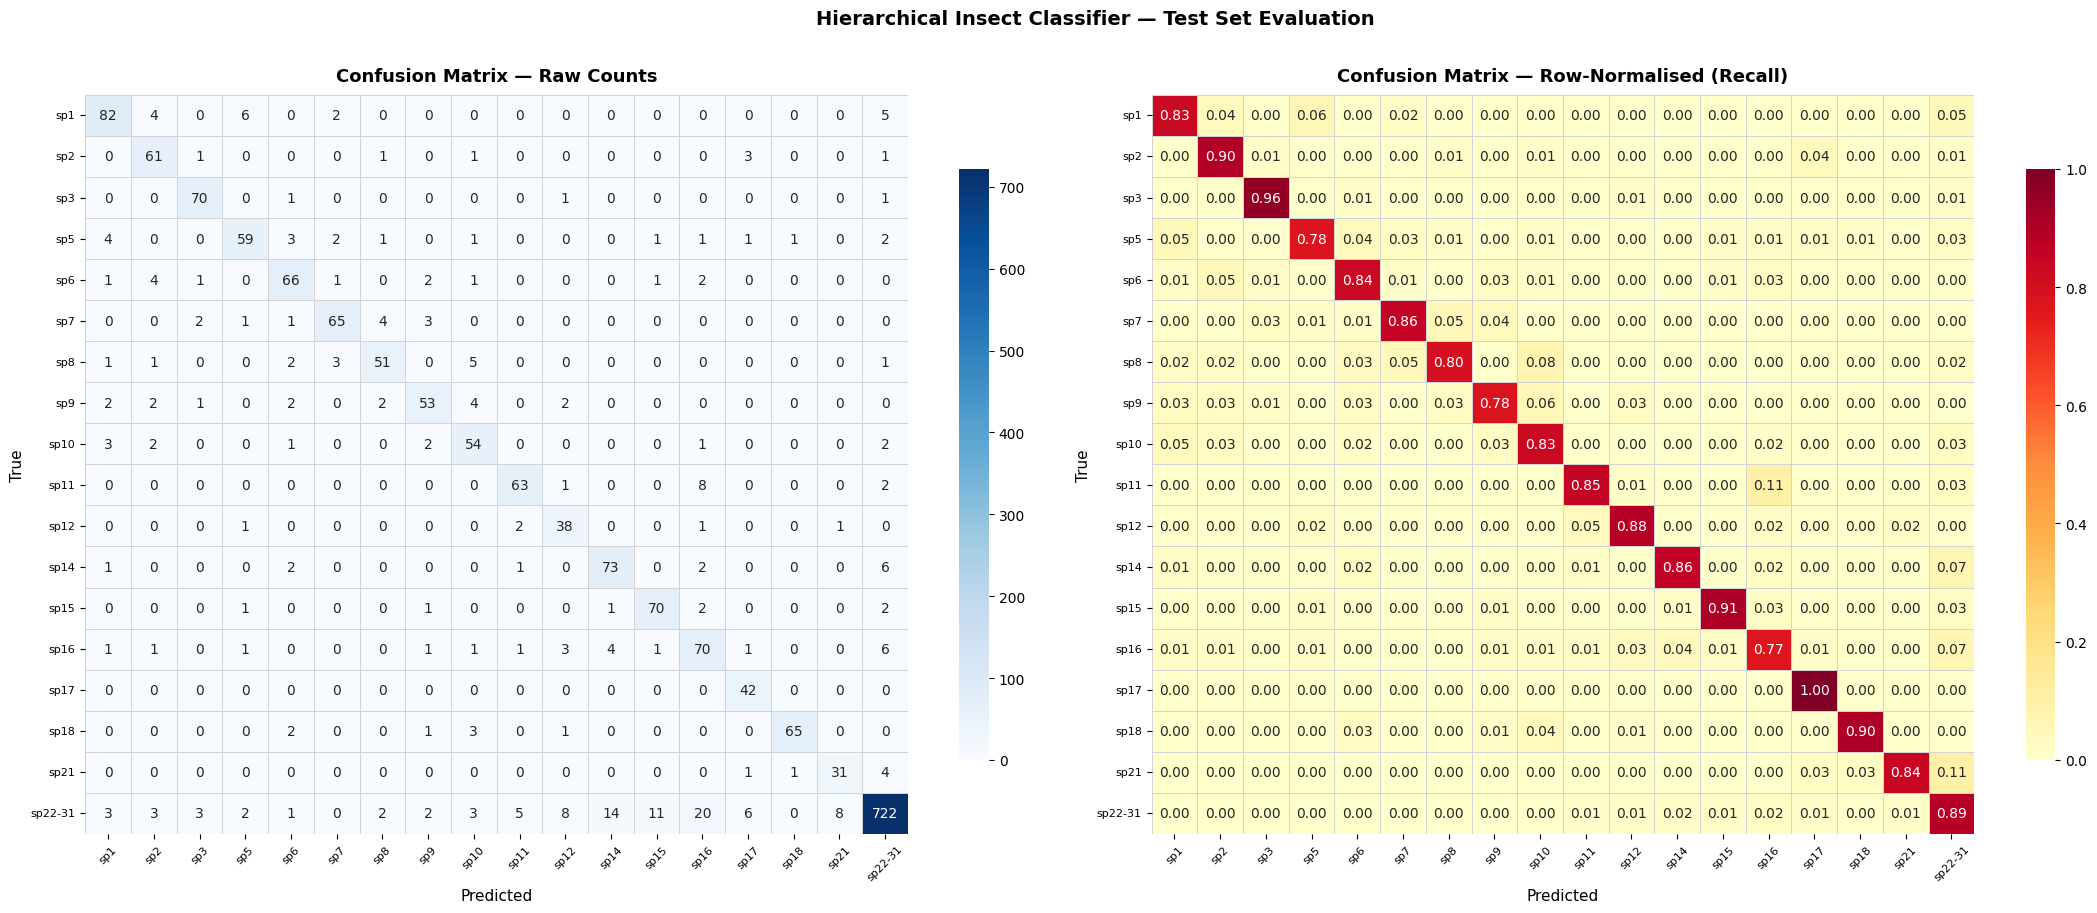

Confusion matrix saved → /workspace/confusion_matrix.png


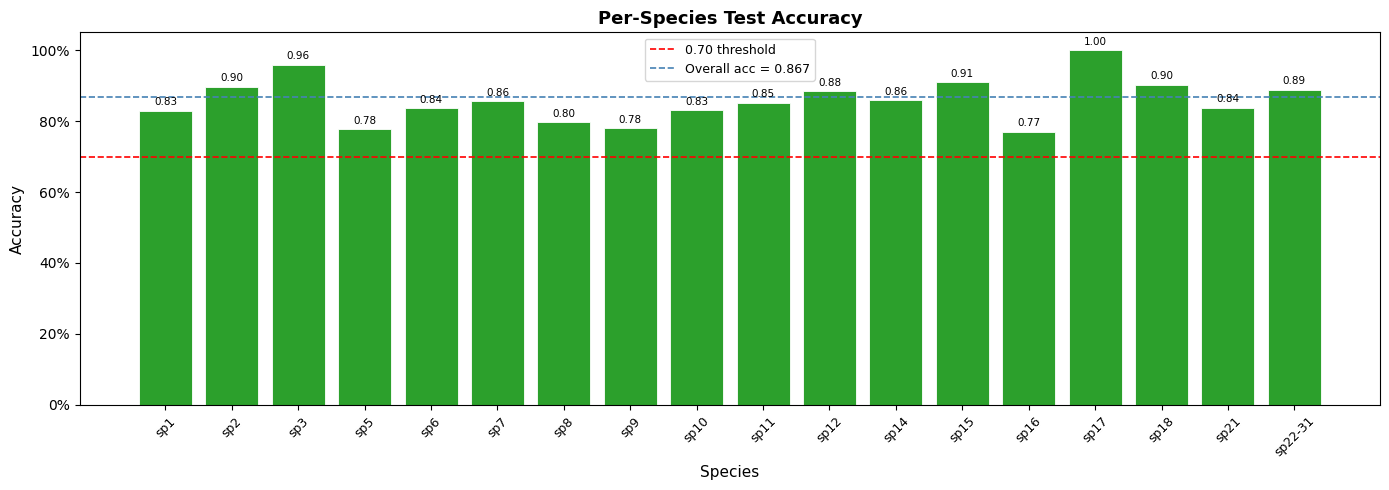

Per-species accuracy chart saved → /workspace/per_species_accuracy.png


In [9]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef,
    balanced_accuracy_score,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ==================== CONFIG ====================
CHECKPOINT_PATH = "/workspace/model_baseline_checkpoints/best_model.pth"
CSV_PATH        = "/workspace/hierarchical_labels_v15_base.csv"
IMG_SIZE        = 224
BATCH_SIZE      = 32
NUM_WORKERS     = 4
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"

# Species label map (after merging 22-31 → 22)
SPECIES_LABEL_MAP = {
    1:  "sp1",
    2:  "sp2",
    3:  "sp3",
    5:  "sp5",
    6:  "sp6",
    7:  "sp7",
    8:  "sp8",
    9:  "sp9",
    10: "sp10",
    11: "sp11",
    12: "sp12",
    14: "sp14",
    15: "sp15",
    16: "sp16",
    17: "sp17",
    18: "sp18",
    21: "sp21",
    22: "sp22-31",
}
# Ordered list of species IDs used throughout
ALL_SPECIES = sorted(SPECIES_LABEL_MAP.keys())
SPECIES_NAMES = [SPECIES_LABEL_MAP[s] for s in ALL_SPECIES]


def merge_sp(sid):
    """Collapse sp22-31 → 22 to match the hierarchy terminal node."""
    return 22 if 22 <= int(sid) <= 31 else int(sid)


# ==================== LOAD DATA & MODEL ====================
test_ds     = HierarchicalInsectDataset(CSV_PATH, split="test", img_size=IMG_SIZE)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

model_eval = EfficientNetHierarchicalBaseline(
    backbone="efficientnet_b0", pretrained=False, feat_dim=512
).to(DEVICE)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model_eval.load_state_dict(ckpt["model_state_dict"])
model_eval.eval()
print(f"Loaded epoch {ckpt['epoch']}  (saved val acc: {ckpt['val_species_acc']:.4f})")

# ==================== INFERENCE ====================
all_preds   = []
all_targets = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="TEST"):
        images = images.to(DEVICE, non_blocking=True)
        labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}

        outputs = model_eval(images)
        sp_pred = predict_species_id(outputs).cpu().numpy()
        sp_tgt  = labels["species_id"].cpu().numpy()

        for pred, tgt in zip(sp_pred, sp_tgt):
            all_targets.append(merge_sp(tgt))
            all_preds.append(merge_sp(pred) if pred != -1 else -1)

all_targets = np.array(all_targets)
all_preds   = np.array(all_preds)

# ==================== 1. PER-SPECIES TABLE ====================
print(f"\n{'='*80}")
print("TEST RESULTS — per species")
print(f"{'='*80}")
print(f"{'Species':<16} {'Acc':>7} {'Precision':>10} {'Recall':>8} {'F1':>8} "
      f"{'Correct':>9} {'Total':>7}")
print(f"{'-'*80}")

total_correct = total_samples = 0
per_species_acc = {}

for sid in ALL_SPECIES:
    mask    = all_targets == sid
    total   = mask.sum()
    if total == 0:
        continue
    correct = (all_preds[mask] == sid).sum()
    acc     = correct / total

    # Per-class precision / recall / F1 (one-vs-rest)
    y_true_bin = (all_targets == sid).astype(int)
    y_pred_bin = (all_preds   == sid).astype(int)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec  = recall_score(y_true_bin,    y_pred_bin, zero_division=0)
    f1   = f1_score(y_true_bin,        y_pred_bin, zero_division=0)

    flag  = " ⚠️" if acc < 0.70 else ""
    label = SPECIES_LABEL_MAP[sid]
    print(f"{label:<16} {acc:>7.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} "
          f"{correct:>9} {total:>7}{flag}")

    per_species_acc[sid] = acc
    total_correct += correct
    total_samples += total

overall_acc = total_correct / total_samples if total_samples else 0.0
print(f"{'-'*80}")
print(f"{'OVERALL':<16} {overall_acc:>7.4f}")

# ==================== 2. AGGREGATE METRICS ====================
# Filter to valid predictions only
valid = all_preds != -1
y_true = all_targets[valid]
y_pred = all_preds[valid]
labels_present = [s for s in ALL_SPECIES if s in y_true]

macro_p  = precision_score(y_true, y_pred, labels=labels_present, average="macro",  zero_division=0)
macro_r  = recall_score(   y_true, y_pred, labels=labels_present, average="macro",  zero_division=0)
macro_f1 = f1_score(       y_true, y_pred, labels=labels_present, average="macro",  zero_division=0)

weighted_p  = precision_score(y_true, y_pred, labels=labels_present, average="weighted", zero_division=0)
weighted_r  = recall_score(   y_true, y_pred, labels=labels_present, average="weighted", zero_division=0)
weighted_f1 = f1_score(       y_true, y_pred, labels=labels_present, average="weighted", zero_division=0)

bal_acc = balanced_accuracy_score(y_true, y_pred)
kappa   = cohen_kappa_score(y_true, y_pred)
mcc     = matthews_corrcoef(y_true, y_pred)

print(f"\n{'='*80}")
print("AGGREGATE METRICS")
print(f"{'='*80}")
print(f"  {'Metric':<30} {'Macro':>10} {'Weighted':>10}")
print(f"  {'-'*50}")
print(f"  {'Precision':<30} {macro_p:>10.4f} {weighted_p:>10.4f}")
print(f"  {'Recall':<30} {macro_r:>10.4f} {weighted_r:>10.4f}")
print(f"  {'F1 Score':<30} {macro_f1:>10.4f} {weighted_f1:>10.4f}")
print(f"  {'-'*50}")
print(f"  {'Overall Accuracy':<30} {overall_acc:>10.4f}")
print(f"  {'Balanced Accuracy':<30} {bal_acc:>10.4f}")
print(f"  {'Cohen Kappa':<30} {kappa:>10.4f}")
print(f"  {'Matthews Corr Coef (MCC)':<30} {mcc:>10.4f}")

# ==================== 3. SKLEARN CLASSIFICATION REPORT ====================
print(f"\n{'='*80}")
print("FULL CLASSIFICATION REPORT")
print(f"{'='*80}")
target_names = [SPECIES_LABEL_MAP[s] for s in labels_present]
print(classification_report(
    y_true, y_pred,
    labels=labels_present,
    target_names=target_names,
    zero_division=0,
    digits=4,
))

# ==================== 4. CONFUSION MATRIX ====================
cm = confusion_matrix(y_true, y_pred, labels=labels_present)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Raw counts
sns.heatmap(
    cm, ax=axes[0],
    xticklabels=target_names, yticklabels=target_names,
    annot=True, fmt="d", cmap="Blues",
    linewidths=0.4, linecolor="lightgrey",
    cbar_kws={"shrink": 0.8},
)
axes[0].set_title("Confusion Matrix — Raw Counts", fontsize=13, fontweight="bold", pad=10)
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("True", fontsize=11)
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0,  labelsize=8)

# Row-normalised (recall per class on diagonal)
sns.heatmap(
    cm_norm, ax=axes[1],
    xticklabels=target_names, yticklabels=target_names,
    annot=True, fmt=".2f", cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.4, linecolor="lightgrey",
    cbar_kws={"shrink": 0.8},
)
axes[1].set_title("Confusion Matrix — Row-Normalised (Recall)", fontsize=13, fontweight="bold", pad=10)
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("True", fontsize=11)
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0,  labelsize=8)

plt.suptitle("Hierarchical Insect Classifier — Test Set Evaluation", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/workspace/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved → /workspace/confusion_matrix.png")

# ==================== 5. PER-SPECIES BAR CHART ====================
sids   = [s for s in ALL_SPECIES if s in per_species_acc]
accs   = [per_species_acc[s] for s in sids]
names  = [SPECIES_LABEL_MAP[s] for s in sids]
colors = ["#d62728" if a < 0.70 else "#2ca02c" for a in accs]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, accs, color=colors, edgecolor="white", linewidth=0.6)
ax.axhline(0.70, color="red",    linestyle="--", linewidth=1.2, label="0.70 threshold")
ax.axhline(overall_acc, color="steelblue", linestyle="--", linewidth=1.2,
           label=f"Overall acc = {overall_acc:.3f}")
ax.set_ylim(0, 1.05)
ax.set_xlabel("Species", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Per-Species Test Accuracy", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.legend(fontsize=9)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, a + 0.01,
            f"{a:.2f}", ha="center", va="bottom", fontsize=7.5)
plt.tight_layout()
plt.savefig("/workspace/per_species_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Per-species accuracy chart saved → /workspace/per_species_accuracy.png")